# SQuAD Coreference Metrics — Per-Article Analysis

Per-article breakdown of coreference-aware chunking metrics across all 4 strategies.

**Metrics (from `metrics.py`):**
- `cluster_break_rate` — fraction of coreference chains split across chunks (lower = better)
- `edge_cut_rate` — fraction of consecutive mention-pairs crossing a boundary (lower = better)
- `entity_concentration` — avg per-chunk dominance of the most-mentioned entity (higher = better)

> **Note on baseline:** Baseline chunks are tokenized/decoded so character offsets from f-coref
> don't align exactly. Baseline metrics use proportional boundary approximation.

In [1]:
import json
import re
import bisect
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

import sys
sys.path.insert(0, str(Path('.').resolve()))
from metrics import cluster_break_rate, edge_cut_rate, entity_concentration

pd.set_option('display.max_colwidth', 40)
pd.set_option('display.float_format', '{:.4f}'.format)
plt.rcParams.update({
    'font.size': 11,
    'axes.titlesize': 12,
    'figure.titlesize': 13,
})

PARQUET_PATH = Path('squad_testing/data/squad_wiki_full_articles.parquet')
CHUNKS_BASE  = Path('squad_testing/chunks')
CLUSTERS_DIR = Path('clusters/squad')

STRATEGIES = [
    'baseline_258_tok',
    'most_recent_low_acc_258t_w128_wtd',
    'most_recent_258t_w254',
    'nonlinear_258t_w254',
]
STRATEGY_SHORT = {
    'baseline_258_tok':                  'baseline',
    'most_recent_low_acc_258t_w128_wtd': 'mr_low_acc',
    'most_recent_258t_w254':             'mr_w254',
    'nonlinear_258t_w254':               'nonlinear',
}
COLORS = ['steelblue', 'coral', 'mediumseagreen', 'mediumpurple']
METRICS = ['cluster_break_rate', 'edge_cut_rate', 'entity_concentration']

In [2]:
def slugify(title: str) -> str:
    return re.sub(r'[\\/*?:"<>|]', '-', title).strip()


def load_chunks(strategy: str, title: str) -> list[str]:
    if strategy == 'baseline_258_tok':
        path = CHUNKS_BASE / strategy / slugify(title) / 'chunks_output.json'
    else:
        path = CHUNKS_BASE / strategy / (title.replace(' ', '_') + '.json')
    if not path.exists():
        return []
    with open(path) as f:
        return json.load(f)['chunks']


def load_clusters(title: str) -> list:
    path = CLUSTERS_DIR / f'{slugify(title)}.json'
    if not path.exists():
        return []
    with open(path) as f:
        return json.load(f)


def chunk_starts_nonbaseline(chunks):
    starts, pos = [], 0
    for c in chunks:
        starts.append(pos)
        pos += len(c)
    starts.append(pos)
    return starts


def chunk_starts_baseline(article_len, n_chunks):
    if n_chunks == 0:
        return [0, article_len]
    step = article_len / n_chunks
    starts = [int(i * step) for i in range(n_chunks)]
    starts.append(article_len)
    return starts


def mention_to_chunk_id(m_start, starts):
    idx = bisect.bisect_right(starts, m_start) - 1
    return max(0, min(idx, len(starts) - 2))


def build_mention_chunks(clusters, starts):
    return [[mention_to_chunk_id(m[0], starts) for m in cluster] for cluster in clusters]


def compute_metrics(mention_chunks, n_chunks):
    return {
        'cluster_break_rate':   cluster_break_rate(mention_chunks),
        'edge_cut_rate':        edge_cut_rate(mention_chunks),
        'entity_concentration': entity_concentration(mention_chunks, n_chunks),
    }

In [3]:
df_parquet = pd.read_parquet(PARQUET_PATH)
article_map = dict(zip(df_parquet['title'], df_parquet['text']))
titles = sorted(article_map.keys())
titles_with_clusters = [t for t in titles if (CLUSTERS_DIR / f'{slugify(t)}.json').exists()]
print(f'Articles in parquet: {len(titles)}')
print(f'Articles with clusters: {len(titles_with_clusters)}')

Articles in parquet: 412
Articles with clusters: 412


In [4]:
rows = []
for strategy in STRATEGIES:
    for title in titles_with_clusters:
        clusters = load_clusters(title)
        if not clusters:
            continue
        chunks = load_chunks(strategy, title)
        if not chunks:
            continue
        if strategy == 'baseline_258_tok':
            starts = chunk_starts_baseline(len(article_map[title]), len(chunks))
        else:
            starts = chunk_starts_nonbaseline(chunks)
        mc = build_mention_chunks(clusters, starts)
        m = compute_metrics(mc, len(chunks))
        m['strategy']   = strategy
        m['title']      = title
        m['n_chunks']   = len(chunks)
        m['n_clusters'] = len(clusters)
        rows.append(m)

results_df = pd.DataFrame(rows)
print(f'Rows: {len(results_df)}')

Rows: 1540


## Metric Distributions per Strategy

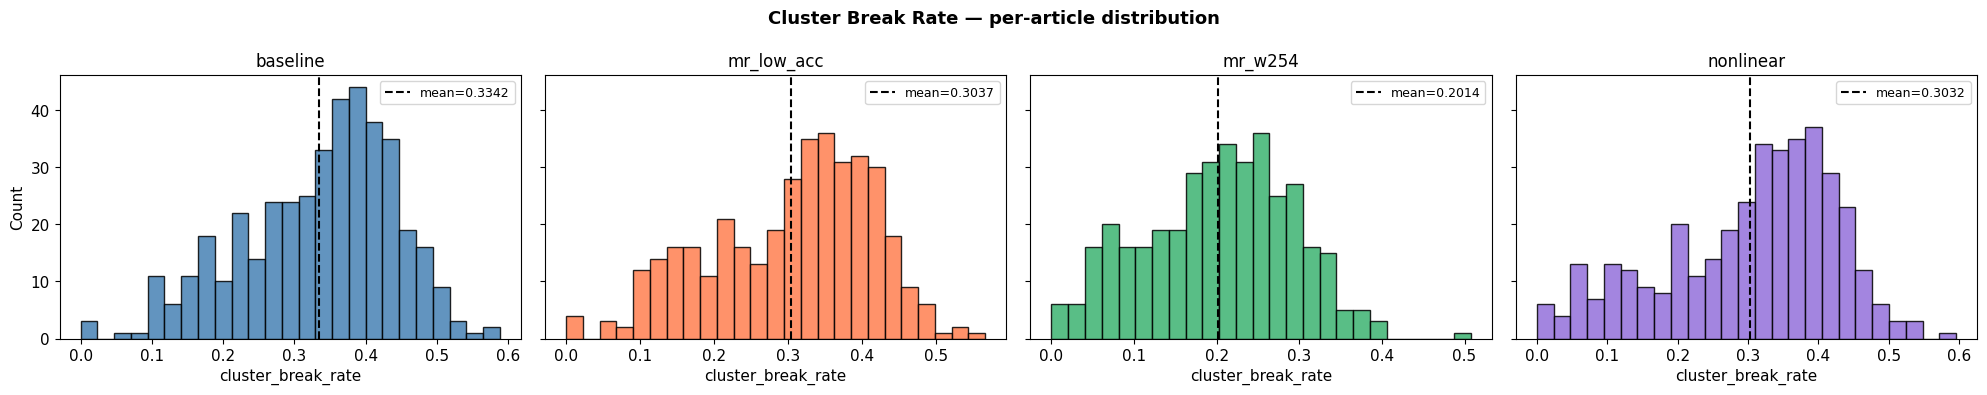

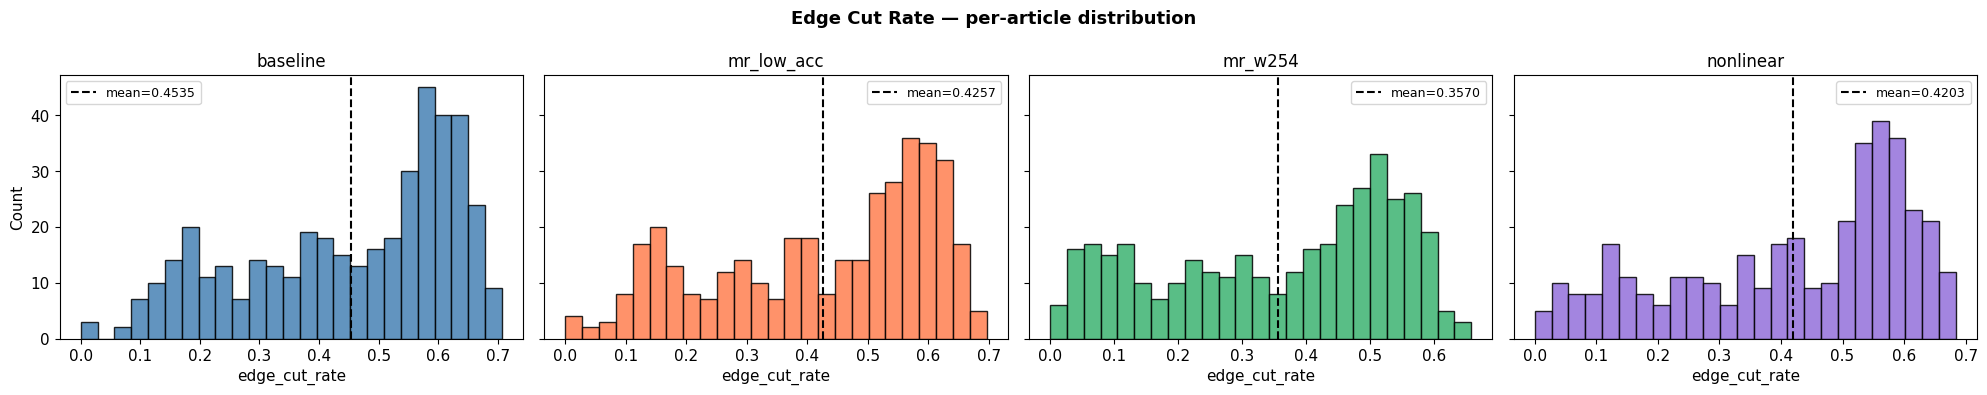

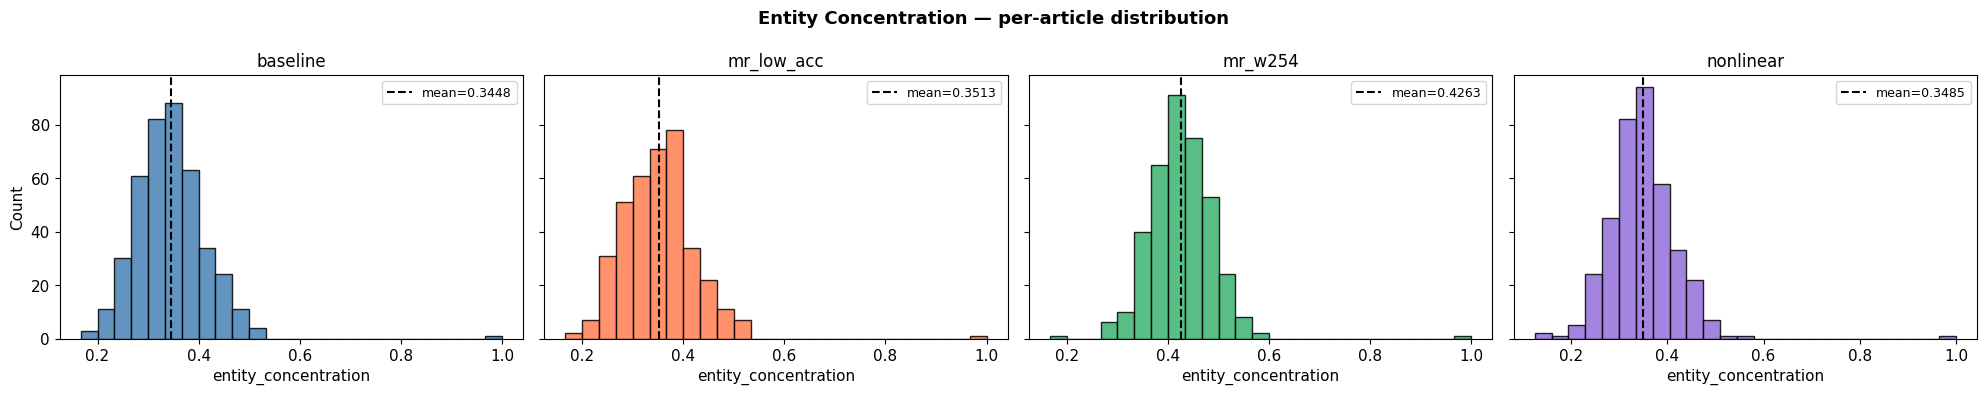

In [5]:
def plot_histograms(df, metric, title_label, bins=25):
    fig, axes = plt.subplots(1, len(STRATEGIES), figsize=(20, 4), sharey=True)
    fig.suptitle(f'{title_label} — per-article distribution', fontweight='bold')
    for ax, strategy, color in zip(axes, STRATEGIES, COLORS):
        sub = df[df['strategy'] == strategy][metric].dropna()
        ax.hist(sub, bins=bins, color=color, edgecolor='black', alpha=0.85)
        ax.axvline(sub.mean(), color='black', linestyle='--', linewidth=1.5,
                   label=f'mean={sub.mean():.4f}')
        ax.set_title(STRATEGY_SHORT[strategy])
        ax.set_xlabel(metric)
        ax.legend(fontsize=9)
    axes[0].set_ylabel('Count')
    plt.tight_layout()
    plt.show()

for metric, label in [
    ('cluster_break_rate',   'Cluster Break Rate'),
    ('edge_cut_rate',        'Edge Cut Rate'),
    ('entity_concentration', 'Entity Concentration'),
]:
    plot_histograms(results_df, metric, label)

## Chunk Length Distributions

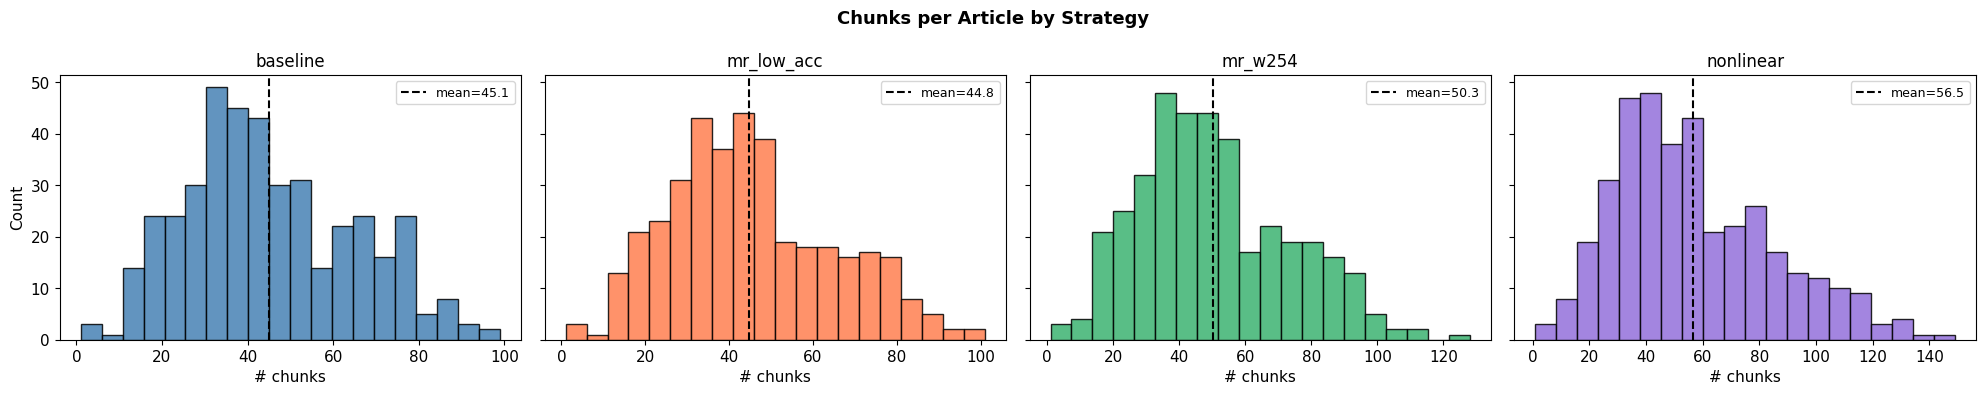

In [6]:
def plot_chunk_lengths():
    fig, axes = plt.subplots(1, len(STRATEGIES), figsize=(20, 4), sharey=True)
    fig.suptitle('Chunks per Article by Strategy', fontweight='bold')
    for ax, strategy, color in zip(axes, STRATEGIES, COLORS):
        sub = results_df[results_df['strategy'] == strategy]['n_chunks'].dropna()
        ax.hist(sub, bins=20, color=color, edgecolor='black', alpha=0.85)
        ax.axvline(sub.mean(), color='black', linestyle='--', linewidth=1.5,
                   label=f'mean={sub.mean():.1f}')
        ax.set_title(STRATEGY_SHORT[strategy])
        ax.set_xlabel('# chunks')
        ax.legend(fontsize=9)
    axes[0].set_ylabel('Count')
    plt.tight_layout()
    plt.show()

plot_chunk_lengths()

## Baseline vs Discourse-Aware — Per-Article Scatter

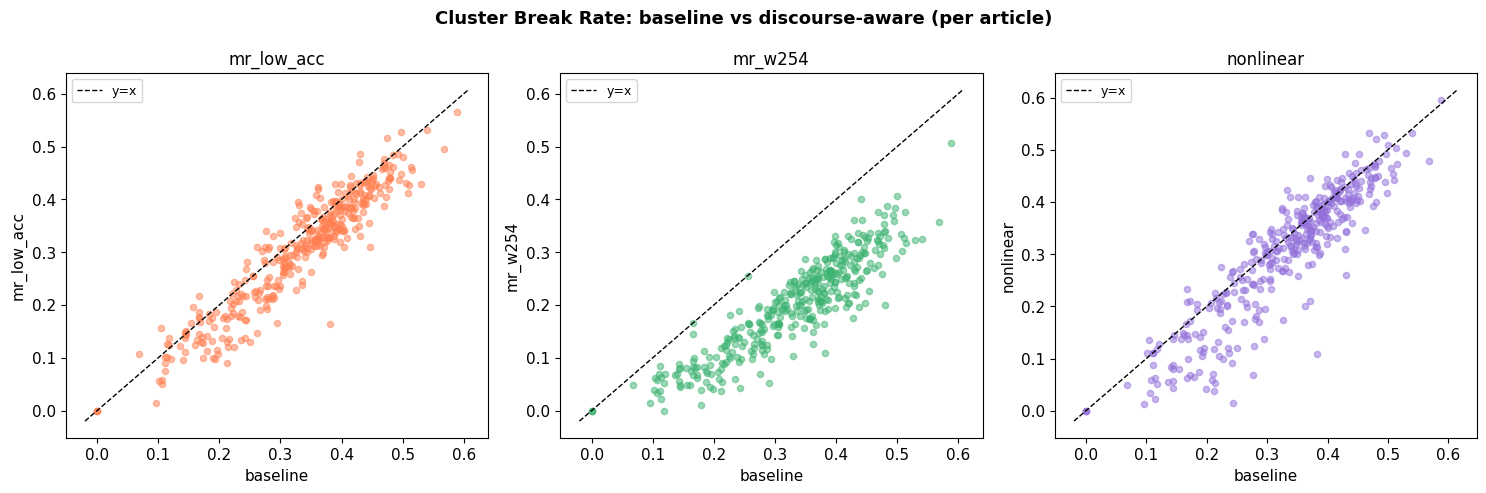

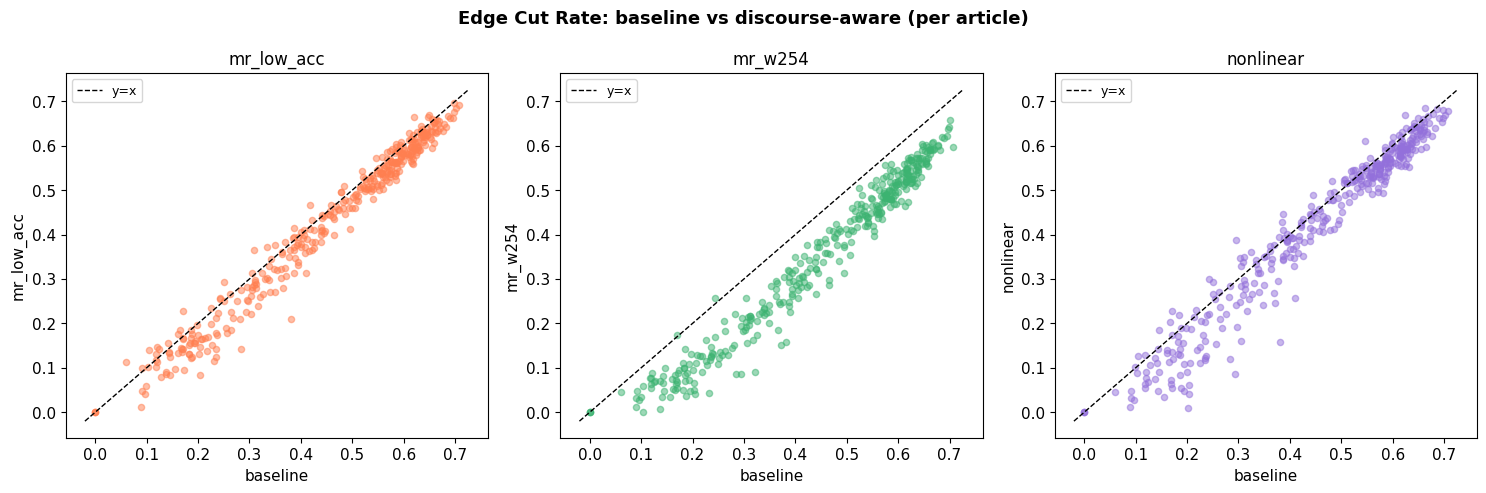

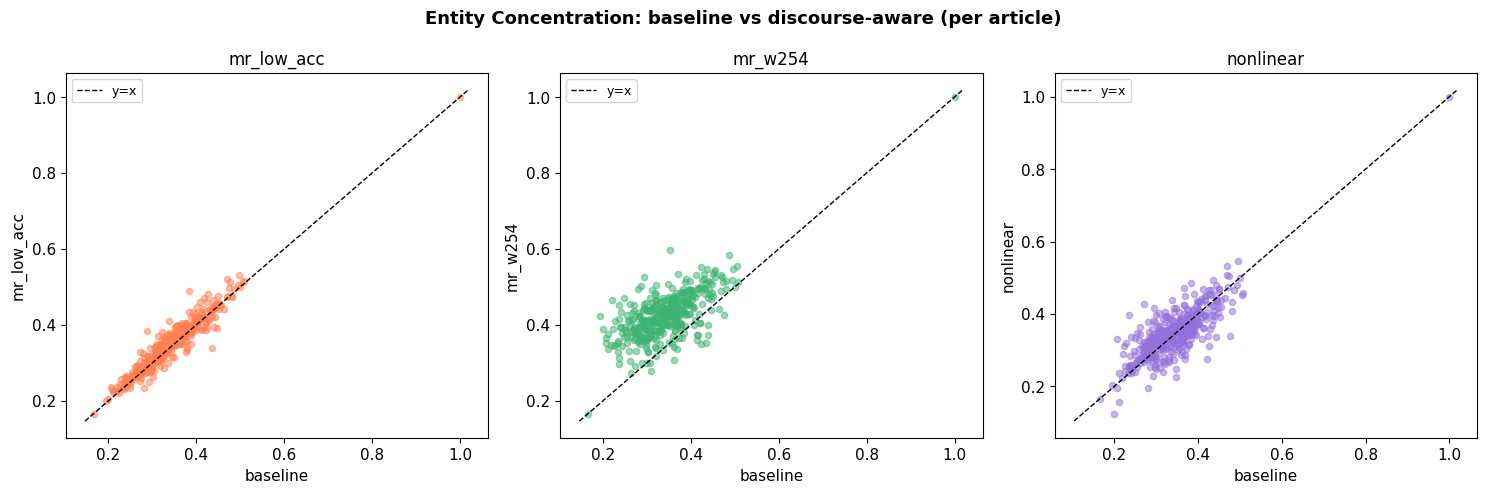

In [7]:
def plot_baseline_vs_coref(metric, title_label):
    baseline_df = results_df[results_df['strategy'] == 'baseline_258_tok'].set_index('title')

    fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=False)
    fig.suptitle(f'{title_label}: baseline vs discourse-aware (per article)', fontweight='bold')

    coref_strategies = [s for s in STRATEGIES if s != 'baseline_258_tok']
    for ax, strategy, color in zip(axes, coref_strategies, COLORS[1:]):
        coref_df = results_df[results_df['strategy'] == strategy].set_index('title')
        common = baseline_df.index.intersection(coref_df.index)
        x = baseline_df.loc[common, metric]
        y = coref_df.loc[common, metric]
        ax.scatter(x, y, color=color, alpha=0.5, s=20)
        lim = (min(x.min(), y.min()) - 0.02, max(x.max(), y.max()) + 0.02)
        ax.plot(lim, lim, 'k--', linewidth=1, label='y=x')
        ax.set_xlabel('baseline')
        ax.set_ylabel(STRATEGY_SHORT[strategy])
        ax.set_title(STRATEGY_SHORT[strategy])
        ax.legend(fontsize=9)

    plt.tight_layout()
    plt.show()

for metric, label in [
    ('cluster_break_rate',   'Cluster Break Rate'),
    ('edge_cut_rate',        'Edge Cut Rate'),
    ('entity_concentration', 'Entity Concentration'),
]:
    plot_baseline_vs_coref(metric, label)

## Top / Bottom Articles per Strategy

In [8]:
STRATEGY  = 'nonlinear_258t_w254'  # change to inspect a different strategy
METRIC    = 'edge_cut_rate'        # change to inspect a different metric
N         = 5

sub = results_df[results_df['strategy'] == STRATEGY].copy()
cols = ['title', 'n_chunks', 'n_clusters', 'cluster_break_rate', 'edge_cut_rate', 'entity_concentration']

print(f'=== TOP {N} (lowest {METRIC}) ===')
display(sub.nsmallest(N, METRIC)[cols].reset_index(drop=True))

print(f'\n=== BOTTOM {N} (highest {METRIC}) ===')
display(sub.nlargest(N, METRIC)[cols].reset_index(drop=True))

=== TOP 5 (lowest edge_cut_rate) ===


,title,n_chunks,n_clusters,cluster_break_rate,edge_cut_rate,entity_concentration
0,Asphalt,1,1,0.0000,0.0000,1.0000
1,Modern history,1,2,0.0000,0.0000,0.5000
2,Universal Studios,1,6,0.0000,0.0000,0.1667
3,Materialism,18,70,0.0143,0.0101,0.4709
4,Nutrition,17,73,0.0137,0.0112,0.2729



=== BOTTOM 5 (highest edge_cut_rate) ===


,title,n_chunks,n_clusters,cluster_break_rate,edge_cut_rate,entity_concentration
0,FC Barcelona,112,285,0.4737,0.6843,0.3068
1,Napoleon,110,339,0.4631,0.6817,0.3300
2,New York City,91,260,0.4654,0.6796,0.3712
3,Dell,69,221,0.4163,0.6772,0.4397
4,Catalan language,51,134,0.4403,0.6721,0.3728
